First cell: we filter stars by astrometric quality, derive physical quantities (distance, absolute magnitude), and loads astrophysical parameters (teff, logg, metallicity) from Gaia's GSP-Phot pipeline for use as ML features. We produce a Color-Magnitude Diagram (observational equivalent of an HR diagram) using two different color indices side by side.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## For 2nd part 
from collections import Counter
from minisom import MiniSom
from scipy.stats import median_abs_deviation

# Load Gaia star catalog CSV and print number of rows (stars) and columns (features)

# ------------------------------------------------------------
# 0. LOAD DATA — quality cuts and absolute magnitudes
# ------------------------------------------------------------


df = pd.read_csv("LolaQuery2-result.csv")
print(f'size of data : {df.shape[0]} rows , {df.shape[1]} columns')

# Compute distance in parsec from parallax in mas
# Convert parallax (in milliarcseconds) to distance in parsecs using d = 1/π . 
# 1pc ~3.26 light-years / ~3.086 E+13 km
df["dist_pc"]  = 1000.0 / df["parallax"]

# Compute absolute magnitude in G band (abs_g) from apparent magnitude ("phot_g_mean_mag") and distance modulus
# Compute the distance modulus and use it to convert apparent G-band magnitude to absolute magnitude (= what each star's brightness would be at a standard 10 pc distance)
distMod= 5.0 -5.0 * np.log10(1000/df['parallax'])
df["abs_G"]     = df["phot_g_mean_mag"]  + distMod
df["abs_Bp"]    = df["phot_bp_mean_mag"] + distMod
df["abs_Rp"]    = df["phot_rp_mean_mag"] + distMod

# The absolute magnitude is the apparent magnitude the star would have if it were all located at a distance of 10 parsec
# Keep only the quality-filtered stars for plotting

# Create a boolean mask keeping only high-quality stars
# parallax_over_error > 100 => parallax measurement is very precise (signal-to-noise > 100)
# ruwe < 1.05 => the astrometric fit is clean (RUWE ≈ 1.0 means a well-behaved single star)
# df["dist_pc"]<105 distance <100 pc (x 3.26) ~326 light year )

distUpper_pc=100
mask = (df['parallax_over_error'] > 200) & (df['ruwe'] < 1.05) & (df["dist_pc"]<distUpper_pc)
df = df.loc[mask].reset_index(drop=True)
print(f"After Quality filter: {len(df)} stars")
print(f'size of data : {df.shape[0]} rows , {df.shape[1]} columns')


size of data : 321302 rows , 20 columns
After Quality filter: 76566 stars
size of data : 76566 rows , 24 columns


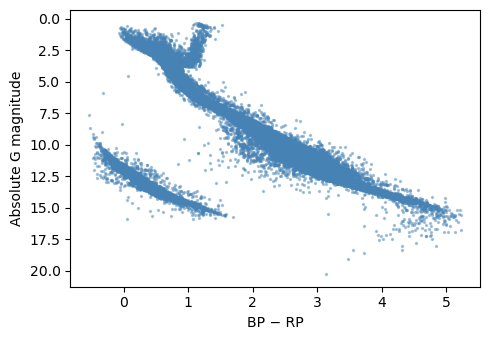

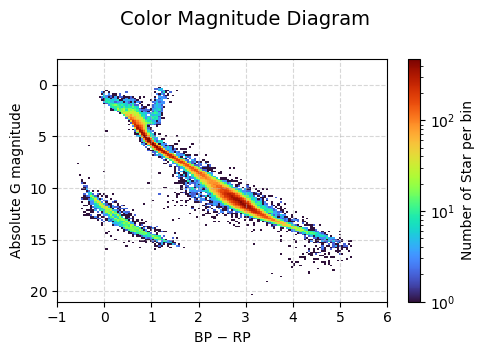

In [71]:


## 1 scatter plot du Color magnitude diagram
fig, ax = plt.subplots(1,1,figsize=(5,3.5))
ax.scatter(df["bp_rp"],df["abs_G"],  s=2, alpha=0.4, c="steelblue")
ax.invert_yaxis()
ax.set_xlabel('BP − RP')
ax.set_ylabel(f"Absolute G magnitude")
plt.tight_layout()

## 2D histogram
nbinx,nbiny = 150,150
fig, ax = plt.subplots(1,1,figsize=(5,3.5))
_, _, _, im = ax.hist2d(
    df.loc[:, "bp_rp"].clip(-1, 6),
    df.loc[:, "abs_G"].clip(-2.5, 21),
    bins=(
    np.linspace(-1, 6, nbinx + 1),
    np.linspace(-2.5, 21, nbiny + 1),
    ),
    cmap='turbo',
    norm='log',
    rasterized=True,
)
vmin, vmax = im.norm.vmin, im.norm.vmax
ax.grid(which='both', linestyle='--', alpha=0.5)
ax.invert_yaxis()
ax.set_xlabel('BP − RP')
ax.set_ylabel(f"Absolute G magnitude")
fig.colorbar(im, ax=ax, label='Number of Star per bin')
fig.suptitle('Color Magnitude Diagram', y=1.00, fontsize=14)
fig.tight_layout()


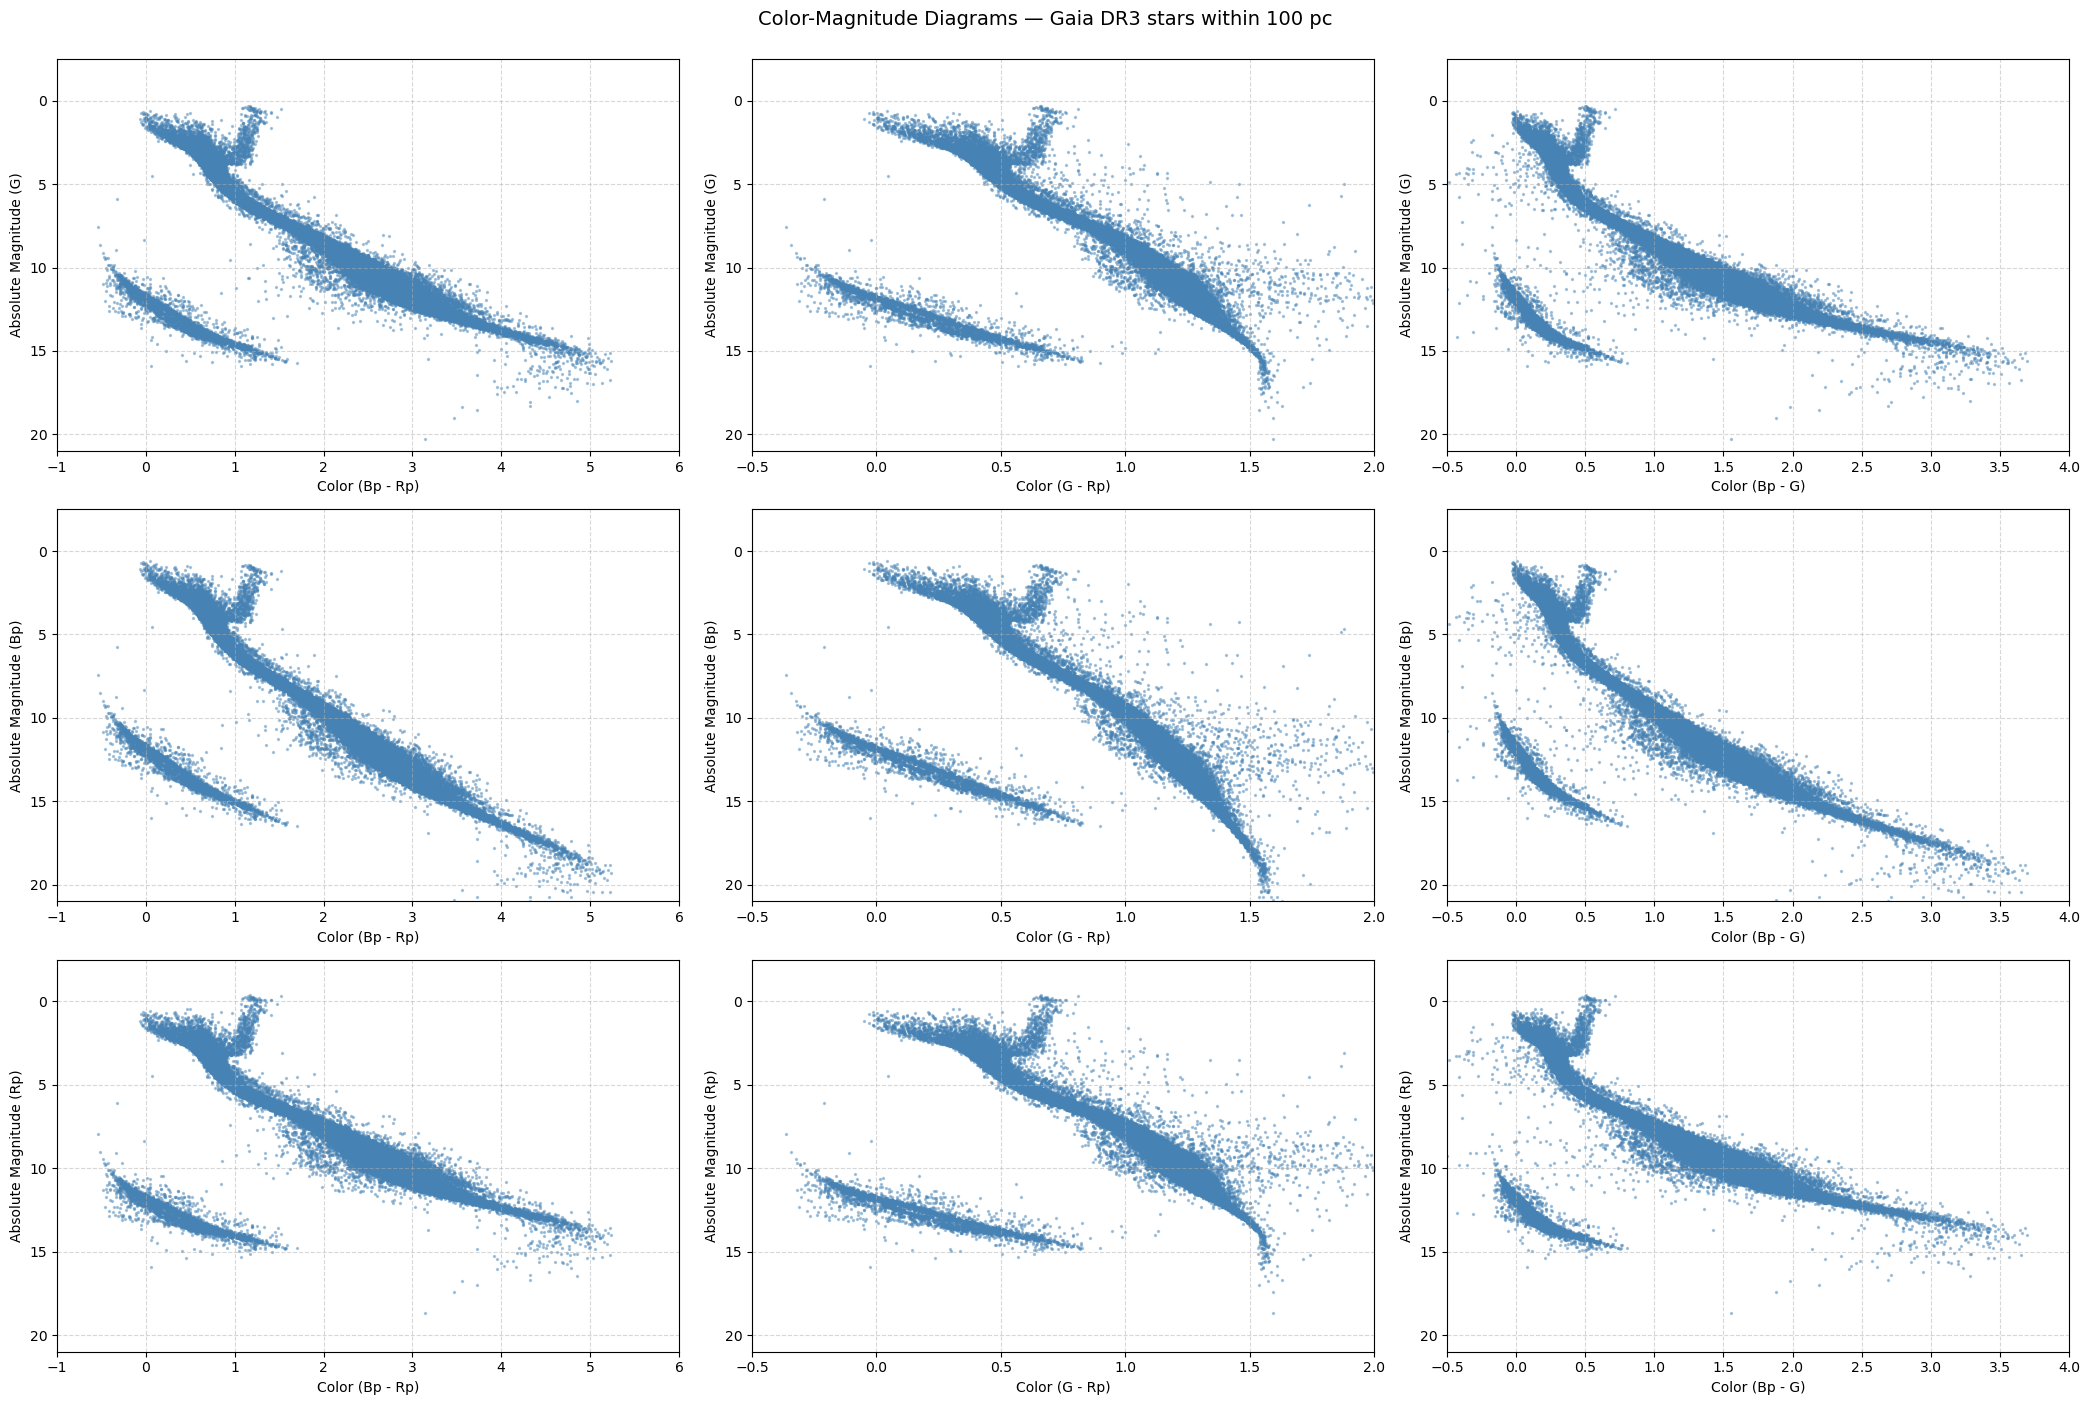

In [72]:
#
# Plot the 9 possible CMDs.
#
# Setup configuration parameters for the plots.
nrows, ncols = 3, 3
#  xkeylbl,xkeyunit,xkey, xscale, xmin, xmax, vlines
correl=    (
    [
      (f'Color (Bp - Rp)', ''      , f'bp_rp'      ,'linear',-1.,6,[]),
      (f'Color (G - Rp)', ''       , f'g_rp'       ,'linear',-0.5,2.,[]),
      (f'Color (Bp - G)', ''      , f'bp_g'      ,'linear',-0.5,4,[]),
      (f'Color (Bp - Rp)', ''      , f'bp_rp'      ,'linear',-1.,6,[]),
      (f'Color (G - Rp)', ''       , f'g_rp'       ,'linear',-0.5,2.,[]),
      (f'Color (Bp - G)', ''      , f'bp_g'      ,'linear',-0.5,4,[]),
      (f'Color (Bp - Rp)', ''      , f'bp_rp'      ,'linear',-1.,6,[]),
      (f'Color (G - Rp)', ''       , f'g_rp'       ,'linear',-0.5,2.,[]),
      (f'Color (Bp - G)', ''      , f'bp_g'      ,'linear',-0.5,4,[]),
    ]
      ,
    [
      (f'Absolute Magnitude (G)', ''       , f'abs_G'       ,'linear',-2.5,21.,[]),
      (f'Absolute Magnitude (G)', ''       , f'abs_G'       ,'linear',-2.5,21,[]),
      (f'Absolute Magnitude (G)', ''       , f'abs_G'       ,'linear',-2.5,21,[]),
      (f'Absolute Magnitude (Bp)', ''       , f'abs_Bp'       ,'linear',-2.5,21.,[]),
      (f'Absolute Magnitude (Bp)', ''       , f'abs_Bp'       ,'linear',-2.5,21,[]),
      (f'Absolute Magnitude (Bp)', ''       , f'abs_Bp'       ,'linear',-2.5,21,[]),      
      (f'Absolute Magnitude (Rp)', ''       , f'abs_Rp'       ,'linear',-2.5,21.,[]),
      (f'Absolute Magnitude (Rp)', ''       , f'abs_Rp'       ,'linear',-2.5,21,[]),
      (f'Absolute Magnitude (Rp)', ''       , f'abs_Rp'       ,'linear',-2.5,21,[]),        
    ]
)
title=f'Color-Magnitude Diagrams — Gaia DR3 stars within {distUpper_pc} pc'
#
# Plot Two Color-Magnitude Diagrams (CMDs)
# Two side-by-side Hertzsprung-Russell style diagrams, both with absolute G magnitude on the Y-axis (inverted, brighter = up)
nbinx,nbiny = 150,150
fig, axs = plt.subplots(3,3,figsize=(21,14))
for idx, (xs, ys) in enumerate(zip(correl[0],correl[1])):
    # we extract all axis parameters for this particular plot
    xkeylbl,xkeyunit,xkey, xscale, xmin, xmax, vlines=xs
    ykeylbl,ykeyunit,ykey, yscale, ymin, ymax, hlines=ys
    if xmin is None:
        xmin, xmax = np.quantile(df[xkey], [0.01, 0.99])
    if ymin is None:
        ymin, ymax = np.quantile(df[ykey], [0.01, 0.99])

    ax = axs.flat[idx]  
    ax.scatter(df[xkey], df[ykey], s=2, alpha=0.4, c="steelblue")
    ax.invert_yaxis()
    ax.set_xlabel(xkeylbl)
    ax.set_ylabel(ykeylbl)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    #plt.title(f'{ykeylbl}_vs_{xkeylbl}')
    ax.grid(which='both', linestyle='--', alpha=0.5)
    if 'abs_' in ykey:
        ax.invert_yaxis()
    fig.suptitle(title, y=1.00, fontsize=14)

        #ax.set_title("Color-Magnitude Diagram — Gaia DR3 stars within 50 pc")
plt.tight_layout()
fig.savefig(f'color_magnitude_diagram_100pc_scatter.pdf')


This is a Hertzsprung-Russell (HR) diagram. We load ~321,000 stars (raw count before quality filter). After quality filters are applied (parallax_over_error > 100 and ruwe < 1.05), only 100,640 stars remain and are actually plotted.

What we see:

1) Main sequence (= diagonal band): the dominant diagonal strip running from top-left to bottom-right is the Main Sequence = stars that are actively fusing hydrogen in their cores (like the Sun).
    - Top-left (bright & blue, BP−RP ≈ −0.3, abs_G ≈ 0–2): Hot, massive O and B-type stars = rare but very luminous
    - Middle (abs_G ≈ 4–5, BP−RP ≈ 0.6–0.8): G-type stars like the Sun (our Sun sits around abs_G ≈ 4.8)
    - Bottom-right (faint & red, BP−RP > 2): Cool, dim M-dwarf red dwarfs = the most numerous stars in the galaxy
      
2) Giant Branch (upper-right clump & plume): the cluster of stars at the top-right (bright but red, abs_G ≈ 0–3, BP−RP ≈ 1–2) are red giants and subgiants = stars that have exhausted their core hydrogen and expanded enormously.
- A subgiant branch peeling off the main sequence around abs_G ≈ 3–4
- The Red Giant Branch (RGB) curving upward-right
- A dense clump around BP−RP ≈ 1, abs_G ≈ 0.5: the Red Clump = low-mass stars in a stable helium-burning phase, used as standard candles in astronomy

3) The White Dwarf Sequence (bottom-left): the separate, isolated cloud of points at bottom-left (faint but blue/white, abs_G ≈ 10–16, BP−RP ≈ −0.5 to 0.5) are white dwarfs = the hot, dense remnants of dead stars. They're clearly separated from the main sequence, forming their own distinct sequence.

Left vs Right Plot:

The two panels show the same stars with different color indices:
1) Left (BP-RP):
- Range: −0.5 to ~5.5;
- Sensitivity: Broad optical range
- White dwarfs: More spread out;
- Red stars: Extended to BP−RP > 4

2) Right (G−RP):
- Range: −0.5 to 2.0;
- Sensitivity: Red-sensitive;
- White dwarfs: Compressed, cleaner separation;
- Red stars: Clipped at G−RP = 2 by xlim

This defines 3 Color-Magnitude Diagrams side by side, each using a different color index on the X-axis but the same luminosity axis on Y. The vlines=[] entries leave room to optionally draw vertical reference lines on any panel.

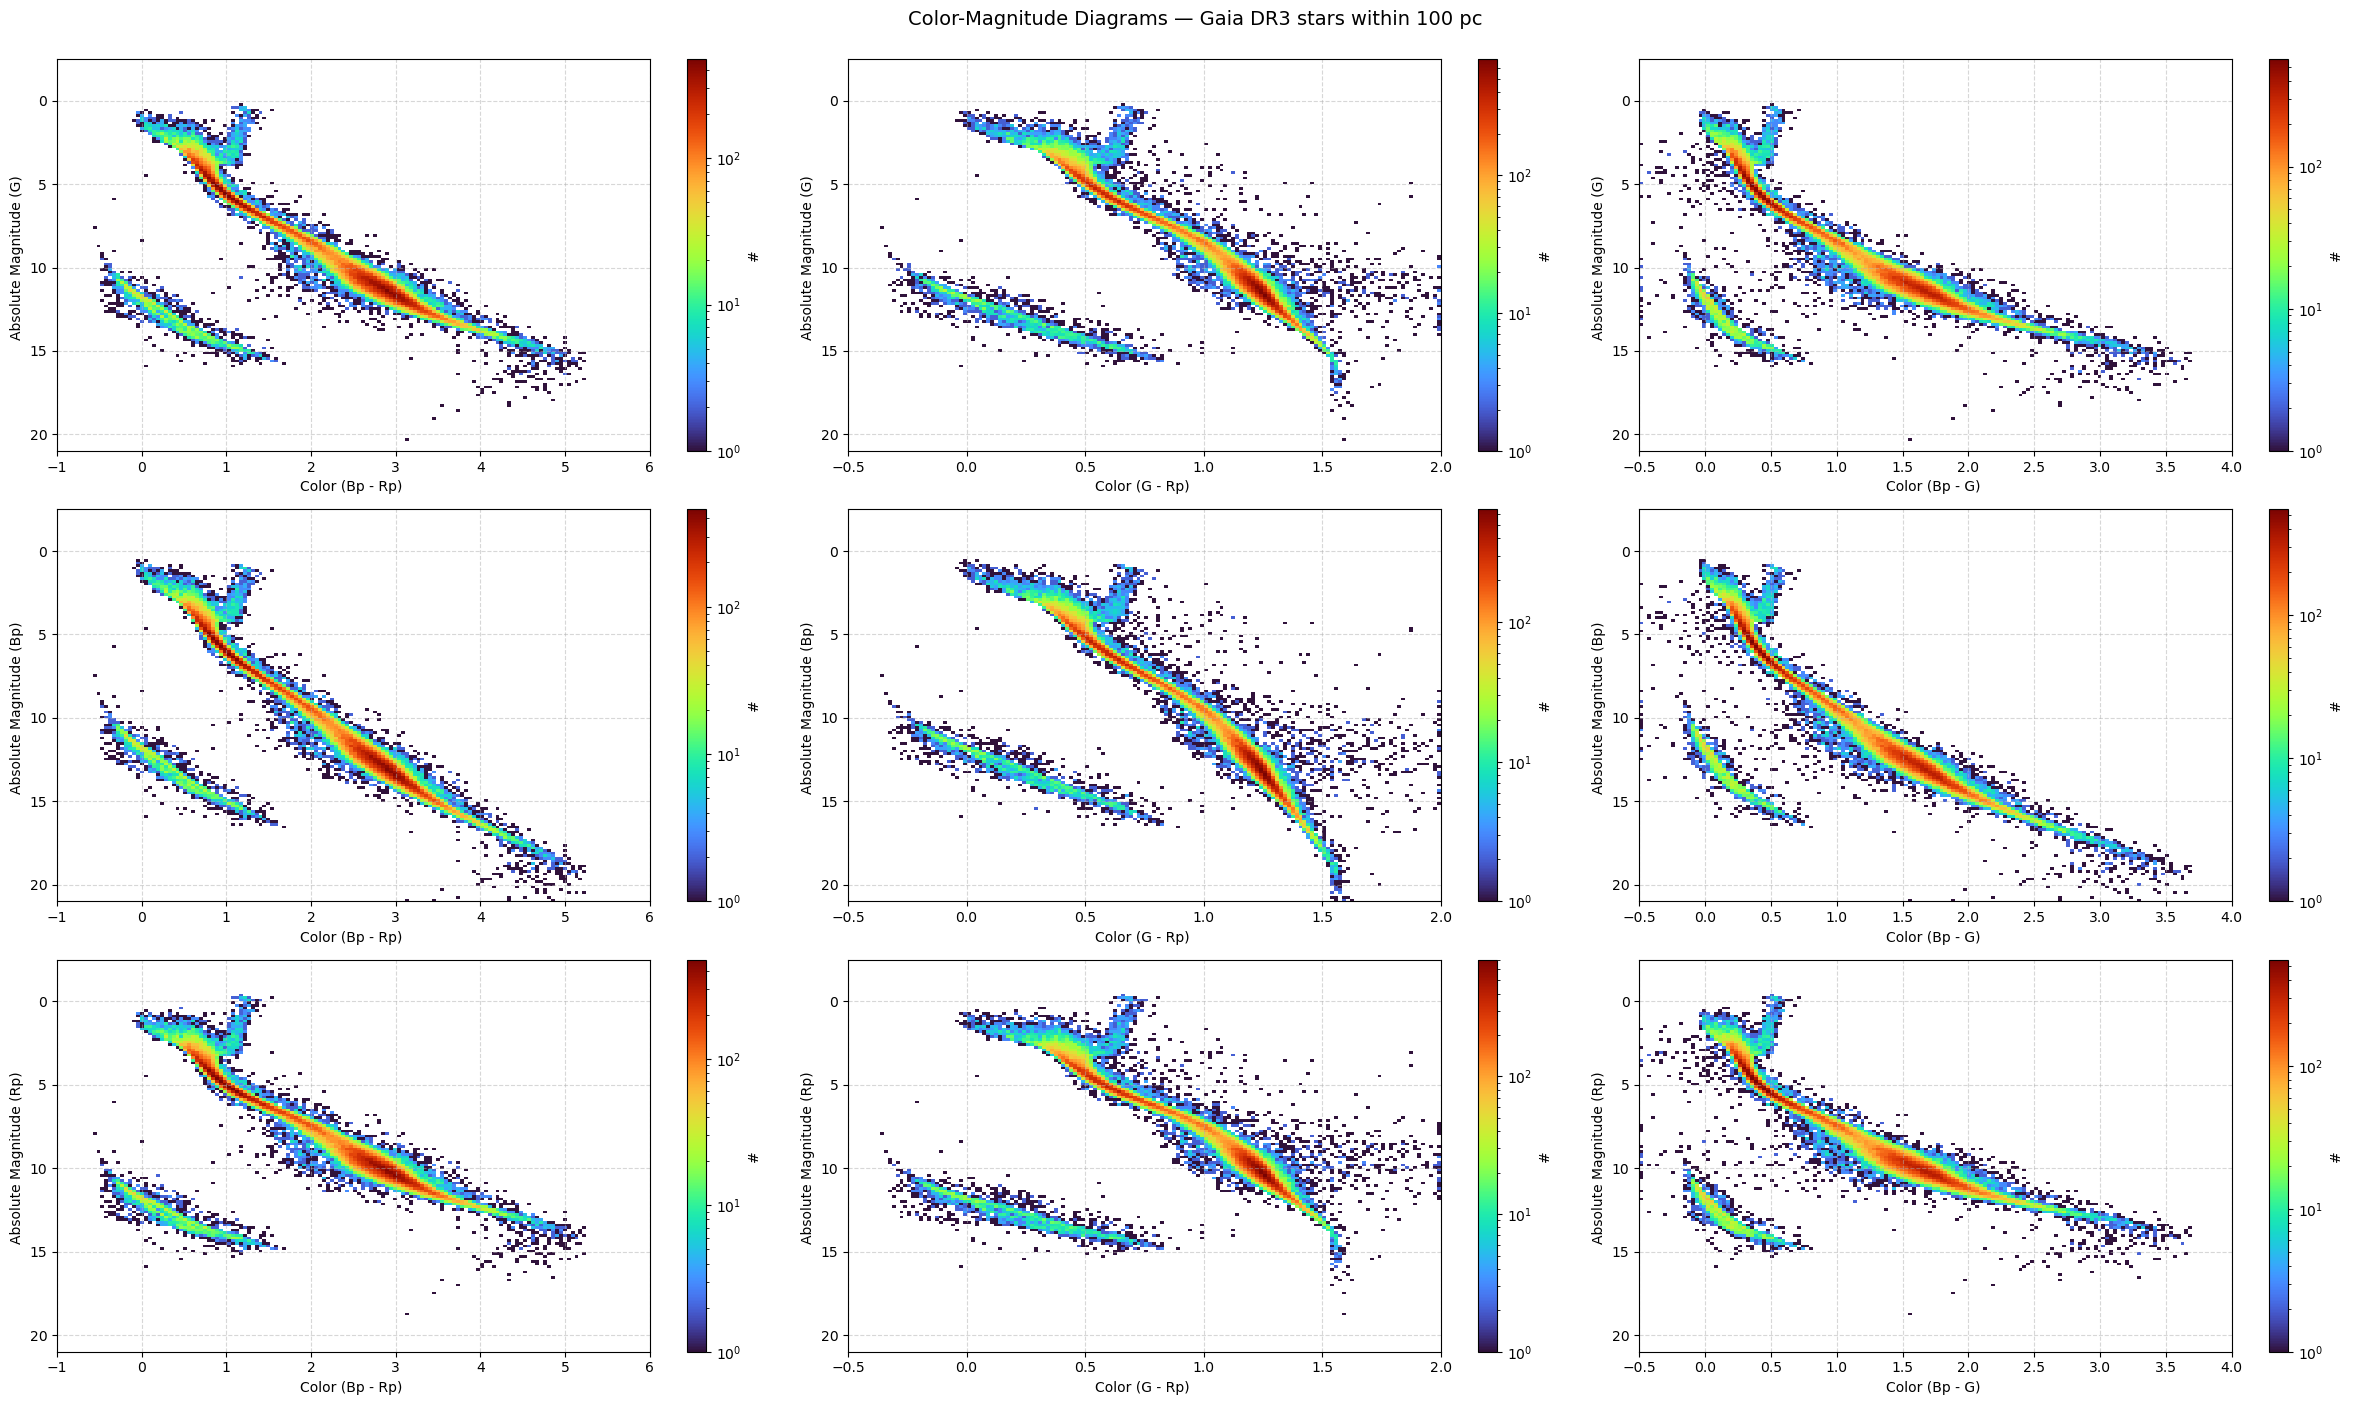

In [73]:
# we iterate over the 3 paired (X-config, Y-config) tuples simultaneously
plot_2d_correl=True
nbinx,nbiny = 150,150
fig, axs = plt.subplots(nrows, ncols, figsize=(24, 14))
count=0
for idx, (xs, ys) in enumerate(zip(correl[0],correl[1])):
    # we extract all axis parameters for this particular plot
    xkeylbl,xkeyunit,xkey, xscale, xmin, xmax, vlines=xs
    ykeylbl,ykeyunit,ykey, yscale, ymin, ymax, hlines=ys
    # If no range was hardcoded, it automatically computes the 1st–99th percentile range from the data, avoiding extreme outliers stretching the axis
    if xmin is None:
        xmin, xmax = np.quantile(df[xkey], [0.01, 0.99])
    if ymin is None:
        ymin, ymax = np.quantile(df[ykey], [0.01, 0.99])

    #fig, ax = plt.subplots(
    #1,1, figsize=(8, 5.1)
    #)
    ax = axs.flat[idx]                        # pick the right cell
    #ax.set_subtitle(title)
      #f'{crit}\n rem. {np.sum(keep)}  (filt. {np.sum(~ind)}, {uniq} unique)'
    # hist2d bins all 321k stars into a 150×150 grid and colors each cell by star count
    # norm='log': log-scaled color so both sparse (white dwarfs) and dense (main sequence) regions are visible simultaneously
    # cmap='turbo': uniform colormap
    # rasterized=True: renders the dense pixel grid as a bitmap inside the PDF, keeping file size small
    # Log or linear bins: chosen dynamically based on xscale/yscale from config
    _, _, _, im = ax.hist2d(
      df.loc[:, xkey].clip(xmin, xmax),
      df.loc[:, ykey].clip(ymin, ymax),
      bins=(
        10 ** np.linspace(np.log10(xmin), np.log10(xmax), nbinx + 1)
        if xscale == 'log'
        else np.linspace(xmin, xmax, nbinx + 1),
        10 ** np.linspace(np.log10(ymin), np.log10(ymax), nbiny + 1)
        if yscale == 'log'
        else np.linspace(ymin, ymax, nbiny + 1),
      ),
      cmap='turbo',
      norm='log',
      rasterized=True,
    )
    vmin, vmax = im.norm.vmin, im.norm.vmax
    #print(f'check Density plot (vmin,vmax)=({vmin}, {vmax})')
    # Adds a color legend showing star counts per bin, but only if the histogram is non-empty
    if vmin!=0 and vmax!=0:
      fig.colorbar(im, ax=ax, label='#')
    ax.set_xlabel(f'{xkeylbl} {xkeyunit}')
    ax.set_ylabel(f'{ykeylbl} {ykeyunit}')
    # Y-axis inverted if plotting absolute magnitude (brighter stars = top)
    if xscale == 'log':
      ax.set_xscale('log')
    if yscale == 'log':
      ax.set_yscale('log')
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    #plt.title(f'{ykeylbl}_vs_{xkeylbl}')
    ax.grid(which='both', linestyle='--', alpha=0.5)
    if 'abs_' in ykey:
        ax.invert_yaxis()

fig.suptitle(title, y=1.00, fontsize=14)
fig.tight_layout()
fig.savefig(f'color_magnitude_diagram_100pc_histo2D.pdf')

#    figsaved=fig.copy()
#    axsaved=ax.copy()


Plot 1: BP−RP vs Absolute G Magnitude
--> This is the broadest color index, spanning the full optical range from blue (BP) to red (RP).

1. Main Sequence (long diagonal, top-left to bottom-right):
- Runs from BP−RP ≈ −0.3 (hot blue stars, abs_G ≈ 0) all the way to BP−RP ≈ 5 (cool red dwarfs, abs_G ≈ 16)
- The densest red core sits around BP−RP ≈ 3–4, abs_G ≈ 11–12 — K/M dwarfs, the most common stars in the solar neighbourhood
- The sequence is the longest and most diagonal of the three plots because BP−RP covers the widest wavelength baseline

2. Giant Branch (upper-right clump):
- The bright fork at top (abs_G ≈ 0–2, BP−RP ≈ 1–1.5) shows the red giant branch tip and AGB
- A horizontal extension to the left around abs_G ≈ 0 traces hot supergiants and bright giants
- The two "horns" are clearly visible --> RGB tip and AGB diverging
-
White Dwarf Sequence (bottom-left island):
- Sits at BP−RP ≈ −0.5 to 0.3, abs_G ≈ 10–15
- Well separated from the main sequence
- Appears relatively spread out horizontally in this index compared to the other two plots => BP−RP is less efficient at compressing the white dwarf temperature sequence
  
=> Colorbar peaks at ~10² (around 100 stars/bin), lower than Plot 2, because the wider x-axis spreads stars across more bins

Plot 2: G−RP vs Absolute G Magnitude
--> This uses only the red half of the spectrum (G minus RP), giving the most compressed x-axis (−0.5 to 2.0).

1. Main Sequence:
- Still runs diagonally but is more compressed horizontally; the entire sequence fits in just 2 magnitudes of color
The densest core (deep red) sits around G−RP ≈ 0.8–1.0, abs_G ≈ 10–11
- The sequence appears wider and fluffier than in the other plots. G−RP is less discriminating for hot blue stars, so the upper main sequence fans out
The bottom of the sequence curves noticeably rightward at abs_G > 13, tracing the M-dwarf knee where molecular absorption changes the spectral shape

2. Giant Branch:
- The bright fork at top (abs_G ≈ 0–2, G−RP ≈ 0.3–0.7) is well defined
- Notably the giants and upper main sequence are more separated here than in BP−RP; the red-sensitive index distinguishes evolved stars well
- The colorbar peaks at 10³ (over 1,000 stars/bin), which is the highest density of the three plots, because all stars are compressed into a narrow x-range

3. White Dwarf Sequence:
- Sits at G−RP ≈ −0.3 to 0.2, abs_G ≈ 10–14
- This is the cleanest separation from the main sequence of the three plots. There's a visible gap between the WD arc and the bottom of the main sequence
- The arc is tight and well-defined, making G−RP particularly good for identifying white dwarfs

Plot 3: P−G vs Absolute G Magnitude
--> This uses blue minus broad-green, making it most sensitive to the hotter, bluer part of the spectrum.

1. Main Sequence:
- Runs from BP−G ≈ 0 (hot stars, abs_G ≈ 2) to BP−G ≈ 3.7 (cool red dwarfs, abs_G ≈ 15)
- This is the most diagonally stretched of the three sequences: BP−G has the best leverage for separating stellar types across temperature
- The dense red core sits around BP−G ≈ 2, abs_G ≈ 11 --> same K/M dwarf population, just shifted in color
- The sequence is narrow and sharp for solar-type stars, then broadens noticeably below abs_G ≈ 12 where M-dwarf molecular bands start affecting BP more than G

2. Giant Branch:
- The two-horned fork at top (abs_G ≈ −2 to 2, BP−G ≈ 0 to 0.5) is the most visually dramatic of the three plots
- The two prongs are the RGB tip and AGB diverging; especially clear here because BP−G is sensitive to the slight temperature difference between these two populations
- A horizontal spur of blue/cyan points extends left around abs_G ≈ 0, tracing rare hot luminous stars

3. White Dwarf Sequence:
- Sits at BP−G ≈ −0.3 to 0.5, abs_G ≈ 10–14
- Cleanly detached from the main sequence with a clear gap
- The arc curves slightly differently than in the other plots: BP is more affected by WD surface temperature, making the sequence tilt more steeply

In [74]:
df

,source_id,ra,dec,pmra,pmra_error,pmdec,pmdec_error,parallax,parallax_error,parallax_over_error,...,bp_g,g_rp,ruwe,teff_gspphot,logg_gspphot,mh_gspphot,dist_pc,abs_G,abs_Bp,abs_Rp
0,1240631368988288,43.747435,1.985125,-29.843897,0.018951,-160.086756,0.016044,14.787356,0.017554,842.36950,...,1.051060,1.016931,1.026141,3457.7441,4.0027,-1.4478,67.625342,8.844237,9.895297,7.827307
1,2269465015096832,47.634012,2.556930,-49.991255,0.015005,-53.982111,0.013430,14.486505,0.015122,957.98004,...,0.485100,0.638988,0.913177,4913.4060,4.5512,0.0990,69.029763,6.063952,6.549052,5.424965
2,2283071471229952,47.716417,2.821068,-44.355357,0.027783,-25.643165,0.025097,14.372583,0.025533,562.90260,...,1.469840,1.181421,1.042461,NaN,NaN,NaN,69.576917,10.790586,12.260426,9.609164
3,4225083883716480,47.259795,5.527291,174.677921,0.049346,-189.777521,0.047274,17.604867,0.041105,428.28766,...,1.885400,1.300861,1.010208,3044.7708,5.0323,-0.0637,56.802475,12.042786,13.928186,10.741925
4,6364767871053440,42.872139,5.841633,-7.507250,0.028948,-39.044579,0.027413,10.332295,0.032236,320.52466,...,0.136771,0.271978,1.035059,7150.6074,4.1292,-0.7890,96.783919,2.852454,2.989225,2.580476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76561,6910075781915700224,313.433002,-7.033637,37.528180,0.060624,2.972324,0.046704,12.976053,0.058463,221.95149,...,1.961479,1.304138,0.976533,NaN,NaN,NaN,77.065034,12.145787,14.107266,10.841649
76562,6914403532696639616,311.358757,-4.623637,-17.495468,0.030407,-23.529579,0.025293,10.072797,0.028428,354.32208,...,1.379060,1.156708,1.001490,3501.3496,4.8412,-0.2208,99.277290,10.107582,11.486642,8.950874
76563,6914793030394441088,311.856645,-4.223452,-94.645784,0.047743,3.371204,0.033948,24.574118,0.046905,523.91170,...,2.119294,1.343670,0.938049,NaN,NaN,NaN,40.693221,12.752417,14.871711,11.408747
76564,6916444707314015104,313.823403,-3.095892,30.797414,0.021074,-69.070222,0.013913,10.312230,0.020163,511.44516,...,1.099410,1.041571,1.004045,3678.3484,4.5963,-0.3429,96.972235,8.783089,9.882499,7.741518


Stars with full photometry : 76121
White dwarfs (classical)   : 2899
Non-WD with full GSP-Phot  : 44399
Non-WD missing GSP-Phot    : 28823 (will be imputed)
Robust centers / scales:
  bp_rp             median=   1.360   scale=   0.951
  g_rp              median=   0.749   scale=   0.426
  bp_g              median=   0.613   scale=   0.516
  abs_G             median=   6.757   scale=   3.778
  abs_Bp            median=   7.368   scale=   4.356
  abs_Rp            median=   6.009   scale=   3.331
  teff_gspphot      median=4558.318   scale=1583.317
  logg_gspphot      median=   4.587   scale=   0.323
  mh_gspphot        median=  -0.205   scale=   0.284
after ordering : qe=0.4592, te=0.0068
after tuning   : qe=0.1464, te=0.1680   (target te < 0.10)


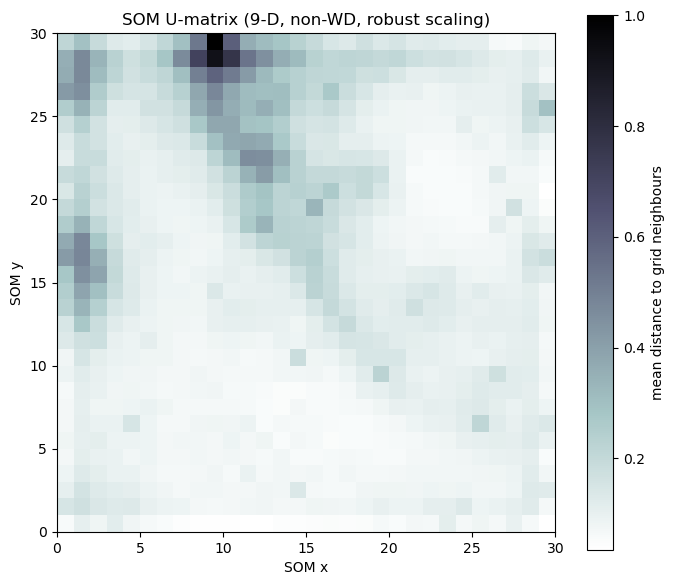


Classical-cut counts (non-WD, GSP-complete):
  MS    : 43816
  GIANT : 192
  SG    : 391

Final population counts:
  MS    : 72780
  WD    : 2899
  GIANT : 168
  SG    : 274
  EMPTY : 0


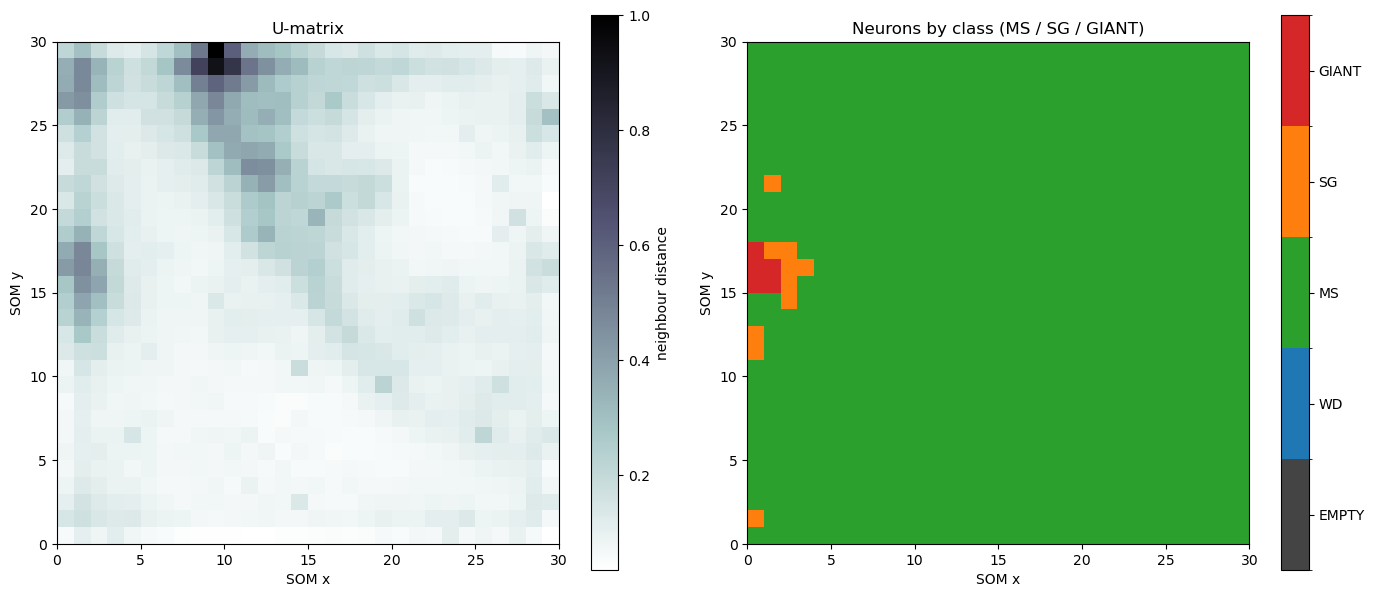

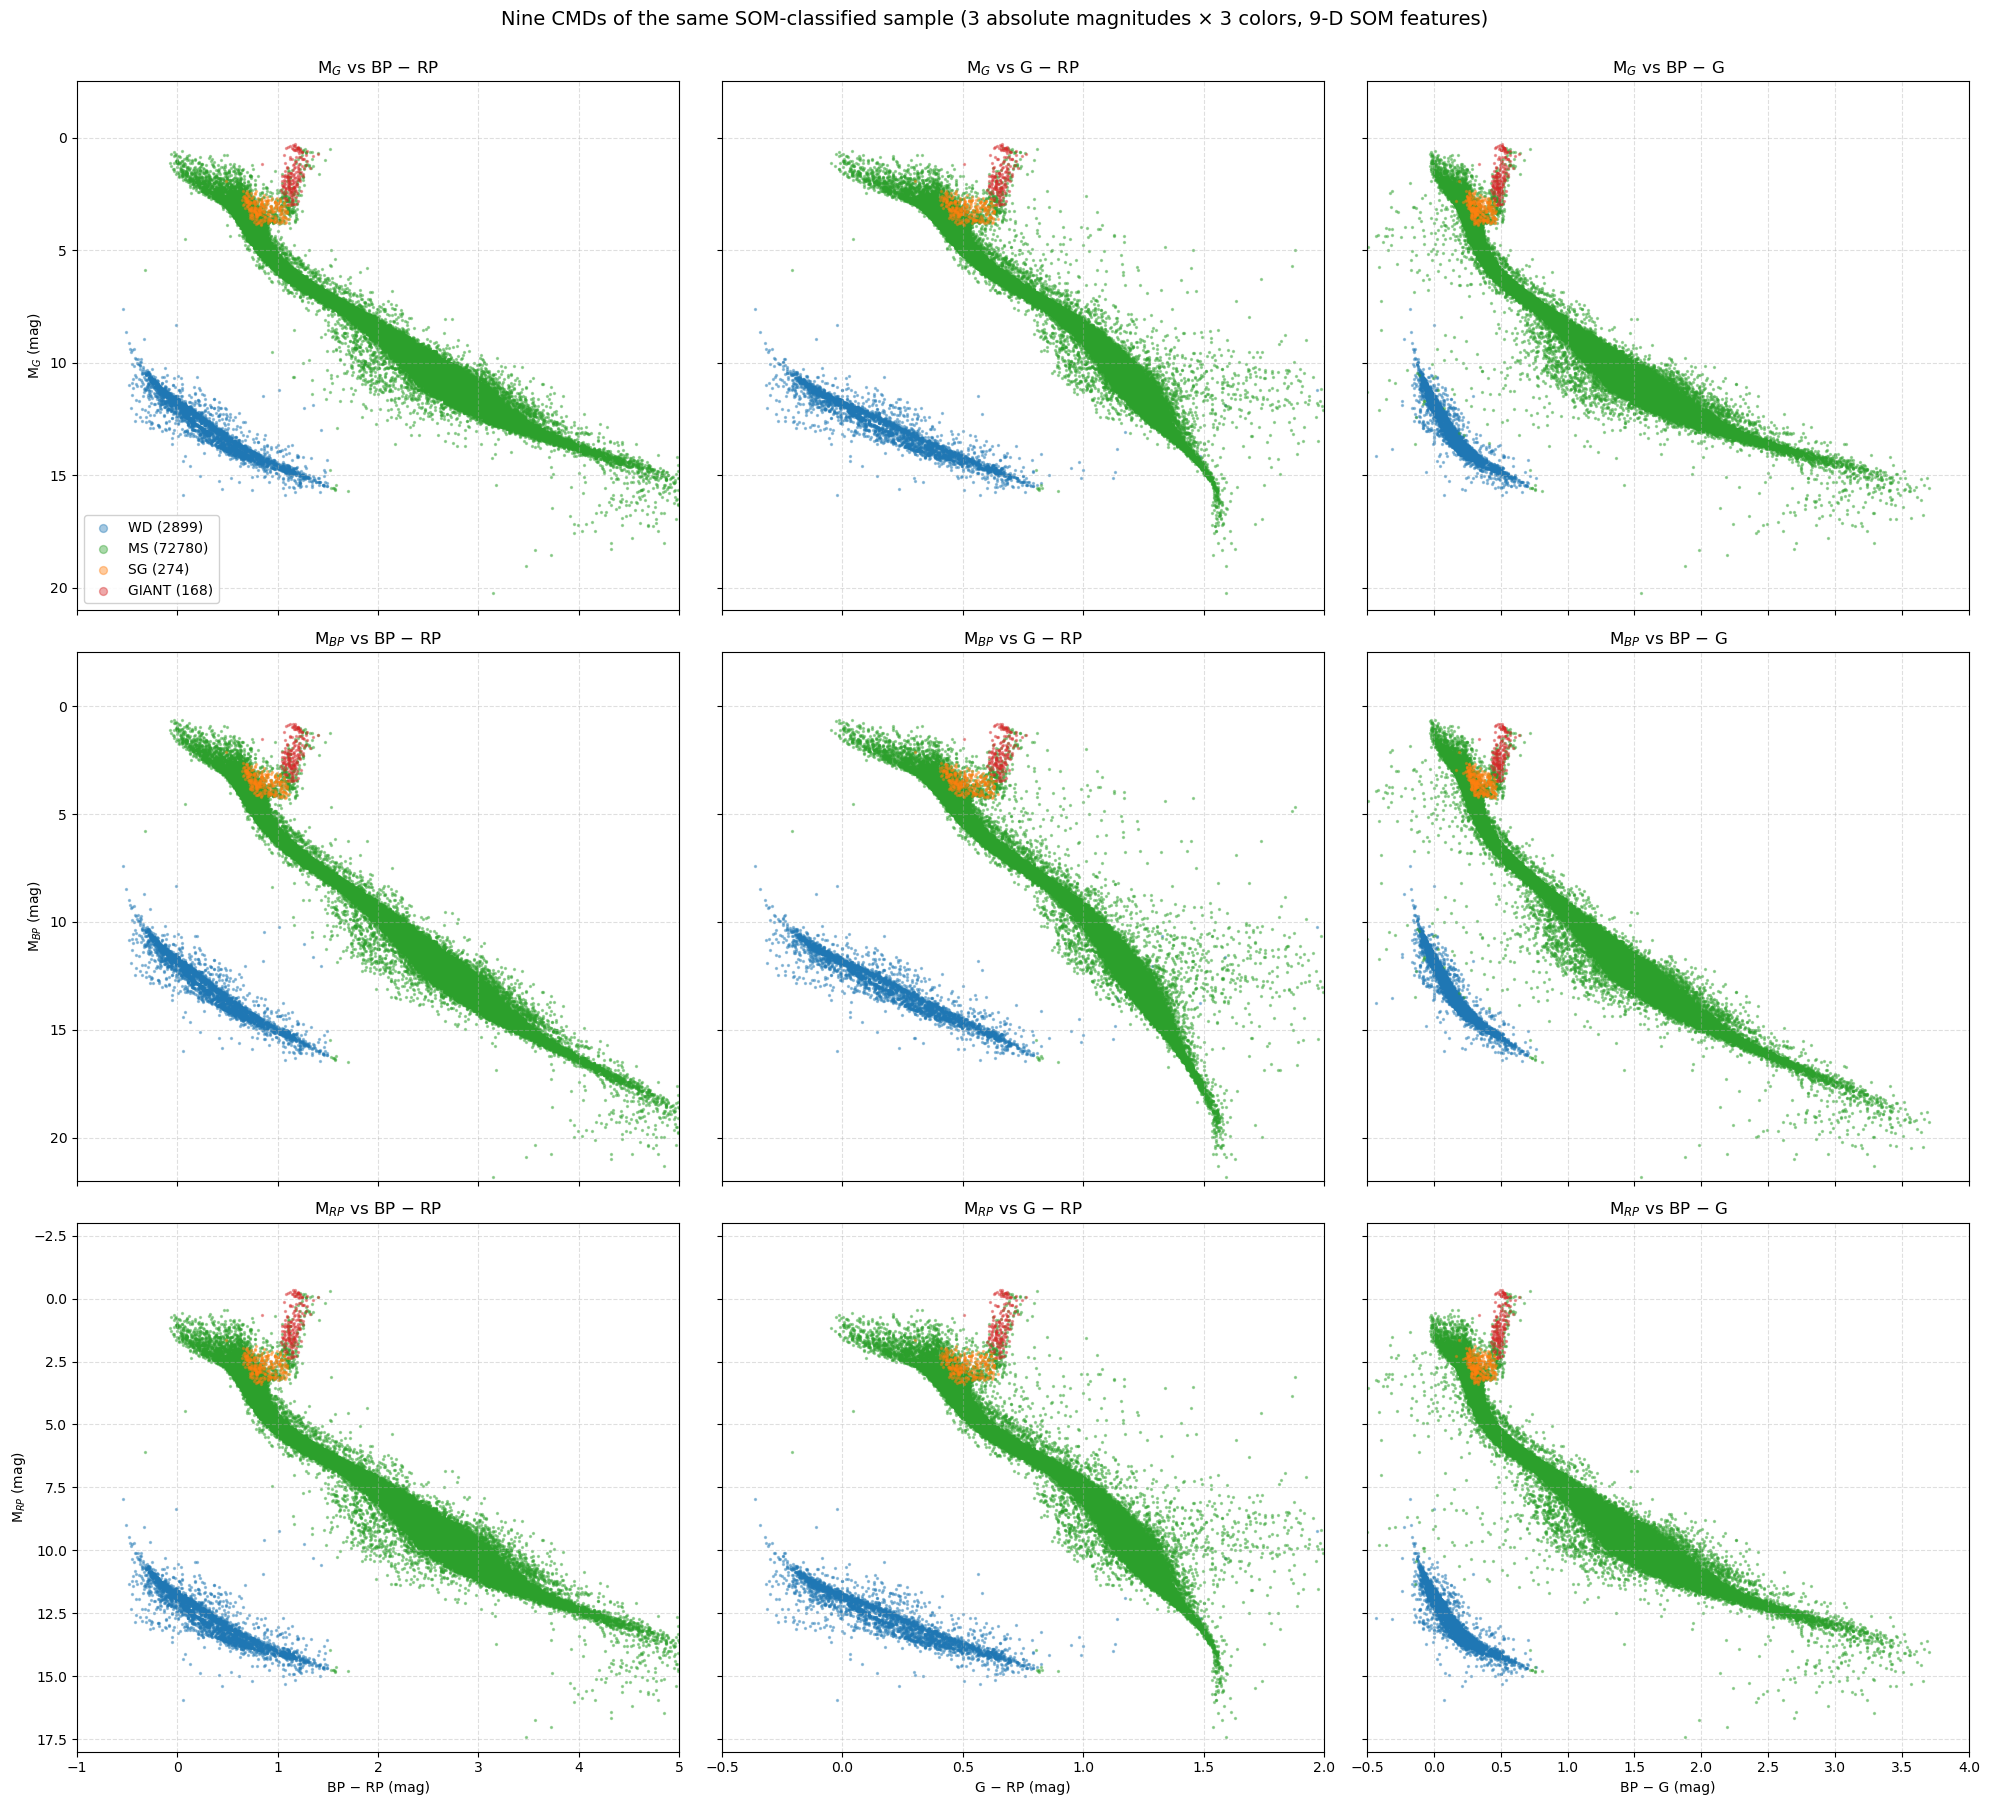


Mean neuron purity : 0.992
Neurons > 90% pure : 876 / 900
Empty neurons      : 0 / 900

Example classifications:
  Sun-like  -> MS
  Red giant -> GIANT
  M-dwarf   -> MS
  WD        -> WD


In [75]:
# ============================================================
#  FULL PIPELINE — Gaia DR3 CMD analysis with SOM
#
#  Stages:
#    1. Load CSV, quality cuts, compute distance + 3 absolute mags
#    2. Pre-classify white dwarfs (Gentile Fusillo+ 2019)
#    3. Robust scaling on 9 features
#    4. Two-phase Kohonen SOM (ordering -> tuning)
#    5. U-matrix
#    6. Route 3 — classical cuts + per-neuron majority vote
#    7. Propagate labels to every star (incl. GSP-imputed)
#    8. Display lattice + 6 CMDs by class
#    9. Purity diagnostics
#   10. classify_new() utility
# ============================================================
# !pip install minisom scipy


# ------------------------------------------------------------
# 1. PRE-CLASSIFY WHITE DWARFS (photometric only)
# ------------------------------------------------------------
cols_color = ["bp_rp", "g_rp", "bp_g"]
cols_absM  = ["abs_G", "abs_Bp", "abs_Rp"]
cols_phot  = cols_color + cols_absM
cols_gsp   = ["teff_gspphot", "logg_gspphot", "mh_gspphot"]
cols_som   = cols_phot + cols_gsp                       # 9 features total

mask_phot  = df[cols_phot].notna().all(axis=1)
df_phot    = df.loc[mask_phot].reset_index(drop=True)

# Region in the CMD that corresponds to White Dwarfs - Easy to identify
#
# M_G > 5·(BP−RP) + 5    AND    M_G > 7    AND    BP−RP < 1.5
#Gentile Fusillo et al. 2019,
#  "A Gaia Data Release 2 catalogue of white dwarfs and a comparison with SDSS",
#  MNRAS 482, 4570 (arXiv:1807.03315).

is_wd = (df_phot["abs_G"] > 5.0 * df_phot["bp_rp"] + 5.0) & \
        (df_phot["abs_G"] > 7.0)                          & \
        (df_phot["bp_rp"]  < 1.5)
print(f"Stars with full photometry : {len(df_phot)}")
print(f"White dwarfs (classical)   : {int(is_wd.sum())}")

# ------------------------------------------------------------
# 2. NON-WD POPULATION — split by GSP-Phot availability
# ------------------------------------------------------------
df_nwd      = df_phot.loc[~is_wd].reset_index(drop=True)
has_gsp     = df_nwd[cols_gsp].notna().all(axis=1)
df_nwd_full = df_nwd.loc[has_gsp].reset_index(drop=True)
print(f"Non-WD with full GSP-Phot  : {len(df_nwd_full)}")
print(f"Non-WD missing GSP-Phot    : {int((~has_gsp).sum())} (will be imputed)")

# ------------------------------------------------------------
# 3. ROBUST SCALING — median / 1.4826*MAD on 9 features
# ------------------------------------------------------------
feat_raw    = df_nwd_full[cols_som].to_numpy()
feat_center = np.median(feat_raw, axis=0)
feat_scale  = median_abs_deviation(feat_raw, axis=0, scale='normal')
feat_scale[feat_scale == 0] = 1.0
feat        = (feat_raw - feat_center) / feat_scale

print("Robust centers / scales:")
for c, m, s in zip(cols_som, feat_center, feat_scale):
    print(f"  {c:16s}  median={m:8.3f}   scale={s:8.3f}")

def zscale_with_impute(arr):
    """Apply (x-median)/scale; NaN -> 0 (= feature median)."""
    out = (arr - feat_center) / feat_scale
    out[np.isnan(out)] = 0.0
    return out

# ------------------------------------------------------------
# 4. SOM — two-phase training, random init
# ------------------------------------------------------------
GRID       = 30
rng        = np.random.default_rng(42)
N_TRAIN    = min(40_000, len(feat))
train_idx  = rng.choice(len(feat), size=N_TRAIN, replace=False)
feat_train = feat[train_idx]

# ---- Phase 1: ORDERING (large sigma, large LR) ----
som = MiniSom(
    x=GRID, y=GRID, input_len=feat.shape[1],
    sigma=GRID / 2, learning_rate=0.5,
    topology='rectangular',
    neighborhood_function='gaussian',
    activation_distance='euclidean',
    random_seed=42,
)
som.random_weights_init(feat_train)
som.train_random(feat_train, num_iteration=5 * N_TRAIN, verbose=False)
print(f"after ordering : qe={som.quantization_error(feat):.4f}, "
      f"te={som.topographic_error(feat):.4f}")

# ---- Phase 2: TUNING (small sigma, small LR) ----
som_tune = MiniSom(
    x=GRID, y=GRID, input_len=feat.shape[1],
    sigma=1.0, learning_rate=0.1,
    topology='rectangular',
    neighborhood_function='gaussian',
    activation_distance='euclidean',
    random_seed=42,
)
som_tune._weights = som._weights.copy()
som_tune.train_random(feat_train, num_iteration=20 * N_TRAIN, verbose=False)
som = som_tune

qe = som.quantization_error(feat)
te = som.topographic_error(feat)
print(f"after tuning   : qe={qe:.4f}, te={te:.4f}   (target te < 0.10)")

# ------------------------------------------------------------
# 5. U-MATRIX (stand-alone)
# ------------------------------------------------------------
umat = som.distance_map()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.pcolormesh(umat.T, cmap="bone_r", shading='auto')
ax.set_aspect('equal')
ax.set_xlabel("SOM x"); ax.set_ylabel("SOM y")
ax.set_title("SOM U-matrix (9-D, non-WD, robust scaling)")
fig.colorbar(im, ax=ax, label="mean distance to grid neighbours")
plt.tight_layout()
plt.savefig("som_umatrix_6cmd.pdf", dpi=300)
plt.show()

# ------------------------------------------------------------
# 6. ROUTE 3 — classical cuts + per-neuron majority vote
# ------------------------------------------------------------
lbl = np.full(len(df_nwd_full), "MS", dtype=object)

gi  = (df_nwd_full["logg_gspphot"] < 3.5) & \
      (df_nwd_full["abs_G"] < 3.0)        & \
      (df_nwd_full["bp_rp"] > 0.9)

sg  = df_nwd_full["logg_gspphot"].between(3.5, 4.0) & \
      df_nwd_full["abs_G"].between(2.5, 4.5)        & \
      df_nwd_full["bp_rp"].between(0.7, 1.1)

lbl[gi.values] = "GIANT"
lbl[sg.values] = "SG"

print("\nClassical-cut counts (non-WD, GSP-complete):")
for k in ["MS", "GIANT", "SG"]:
    print(f"  {k:6s}: {(lbl == k).sum()}")

hits = {}
for x_norm, l in zip(feat, lbl):
    hits.setdefault(som.winner(x_norm), []).append(l)

neuron_label  = np.full((GRID, GRID), "EMPTY", dtype=object)
neuron_purity = np.zeros((GRID, GRID))
neuron_count  = np.zeros((GRID, GRID), dtype=int)
for (i, j), ls in hits.items():
    c = Counter(ls)
    top, n = c.most_common(1)[0]
    neuron_label[i, j]  = top
    neuron_purity[i, j] = n / len(ls)
    neuron_count[i, j]  = len(ls)

# ------------------------------------------------------------
# 7. PROPAGATE LABELS BACK TO EVERY STAR IN df_phot
# ------------------------------------------------------------
star_label_full = np.full(len(df_phot), "EMPTY", dtype=object)
star_label_full[is_wd.values] = "WD"

# non-WD with full GSP -> reuse the BMUs computed on training feat
nwd_full_idx = df_phot.index[~is_wd].to_numpy()[has_gsp.values]
nwd_full_lbl = np.array([neuron_label[som.winner(x)] for x in feat])
star_label_full[nwd_full_idx] = nwd_full_lbl

# non-WD missing GSP -> impute and BMU
nwd_miss_idx = df_phot.index[~is_wd].to_numpy()[(~has_gsp).values]
arr_miss     = df_nwd.loc[~has_gsp, cols_som].to_numpy()
feat_miss    = zscale_with_impute(arr_miss)
nwd_miss_lbl = np.array([neuron_label[som.winner(x)] for x in feat_miss])
star_label_full[nwd_miss_idx] = nwd_miss_lbl

print("\nFinal population counts:")
for k in ["MS", "WD", "GIANT", "SG", "EMPTY"]:
    print(f"  {k:6s}: {(star_label_full == k).sum()}")

# ------------------------------------------------------------
# 8. DISPLAY  (a) lattice diagnostics  (b) the SIX CMDs
# ------------------------------------------------------------
class_to_int = {"EMPTY": -1, "WD": 0, "MS": 1, "SG": 2, "GIANT": 3}
cmap_class   = mcolors.ListedColormap(
    ["#444444", "#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"])
norm_class   = mcolors.BoundaryNorm([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5], cmap_class.N)
neuron_int   = np.vectorize(class_to_int.get)(neuron_label)
class_color  = {"WD": "#1f77b4", "MS": "#2ca02c", "SG": "#ff7f0e",
                "GIANT": "#d62728", "EMPTY": "#bbbbbb"}

# ---- (a) lattice diagnostics ----
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
im0 = axs[0].pcolormesh(umat.T, cmap="bone_r", shading='auto')
axs[0].set_aspect('equal'); axs[0].set_title("U-matrix")
axs[0].set_xlabel("SOM x"); axs[0].set_ylabel("SOM y")
fig.colorbar(im0, ax=axs[0], label="neighbour distance")

im1 = axs[1].pcolormesh(neuron_int.T, cmap=cmap_class, norm=norm_class,
                        shading='auto')
axs[1].set_aspect('equal')
axs[1].set_title("Neurons by class (MS / SG / GIANT)")
axs[1].set_xlabel("SOM x"); axs[1].set_ylabel("SOM y")
cb = fig.colorbar(im1, ax=axs[1], ticks=[-1, 0, 1, 2, 3])
cb.ax.set_yticklabels(["EMPTY", "WD", "MS", "SG", "GIANT"])
plt.tight_layout()
plt.savefig("som_lattice_6cmd.pdf", dpi=300)
plt.show()

# ---- (b) NINE CMDs : 3 absolute magnitudes x 3 colors ---------------
colors_def = [
    ("bp_rp", "BP − RP", (-1.0, 5.0)),
    ("g_rp",  "G − RP",  (-0.5, 2.0)),
    ("bp_g",  "BP − G",  (-0.5, 4.0)),
]
mags_def = [
    ("abs_G",  r"M$_G$",   (21, -2.5)),
    ("abs_Bp", r"M$_{BP}$", (22, -2.5)),
    ("abs_Rp", r"M$_{RP}$", (18, -3.0)),
]

fig, axs = plt.subplots(3, 3, figsize=(20, 18), sharey='row', sharex='col')
for i, (yc, ylbl, ylim) in enumerate(mags_def):
    for j, (xc, xlbl, xlim) in enumerate(colors_def):
        ax = axs[i, j]
        for k, c in class_color.items():
            sel = star_label_full == k
            if sel.any():
                ax.scatter(df_phot.loc[sel, xc], df_phot.loc[sel, yc],
                           s=2, alpha=0.4, c=c,
                           label=f"{k} ({sel.sum()})", rasterized=True)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim)
        if i == 2: ax.set_xlabel(f"{xlbl} (mag)")
        if j == 0: ax.set_ylabel(f"{ylbl} (mag)")
        ax.set_title(f"{ylbl} vs {xlbl}")
        ax.grid(linestyle="--", alpha=0.4)

axs[0, 0].legend(markerscale=4, framealpha=0.9, loc="lower left")
plt.suptitle("Nine CMDs of the same SOM-classified sample "
             "(3 absolute magnitudes × 3 colors, 9-D SOM features)",
             y=1.00, fontsize=14)
plt.tight_layout()
plt.savefig("som_nine_cmds.pdf", dpi=300)
plt.show()

# ------------------------------------------------------------
# 9. PURITY DIAGNOSTIC
# ------------------------------------------------------------
filled = neuron_count > 0
print(f"\nMean neuron purity : {neuron_purity[filled].mean():.3f}")
print(f"Neurons > 90% pure : {(neuron_purity > 0.9).sum()} / {filled.sum()}")
print(f"Empty neurons      : {(~filled).sum()} / {GRID*GRID}")

# ------------------------------------------------------------
# 10. CLASSIFY A NEW STAR — 9 features, GSP-Phot optional
# ------------------------------------------------------------
def classify_new(bp_rp, g_rp, bp_g,
                 abs_G, abs_Bp, abs_Rp,
                 teff=np.nan, logg=np.nan, mh=np.nan):
    """WD via classical cut; otherwise SOM BMU. Missing GSP-Phot -> imputed."""
    if (abs_G > 5.0 * bp_rp + 5.0) and (abs_G > 7.0) and (bp_rp < 1.5):
        return "WD"
    arr = np.array([[bp_rp, g_rp, bp_g,
                     abs_G, abs_Bp, abs_Rp,
                     teff, logg, mh]], dtype=float)
    z   = zscale_with_impute(arr)[0]
    return neuron_label[som.winner(z)]

print("\nExample classifications:")
print("  Sun-like  ->", classify_new(0.82, 0.49, 0.33,
                                      4.67, 5.00, 4.18,
                                      5772, 4.44,  0.0))
print("  Red giant ->", classify_new(1.40, 0.80, 0.60,
                                      0.50, 1.10, -0.30,
                                      4500, 2.50, -0.2))
print("  M-dwarf   ->", classify_new(3.50, 1.40, 2.10,
                                      12.5, 14.6, 11.1,
                                      3300, 4.90,  0.0))
print("  WD        ->", classify_new(0.20, 0.10, 0.10,
                                      12.0, 12.1, 11.9))
